In [2]:
import os
import cv2
import torch
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import RTDETR   # <-- use RTDETR instead of YOLO
import albumentations as A

if torch.cuda.is_available():
    device = 0
    gpu_name = torch.cuda.get_device_name(0)
    print(f"SUCCESS: High-Performance GPU Detected: {gpu_name}")
    print("Training will be fast.")
else:
    device = 'cpu'
    print("WARNING: No GPU detected. We are using the CPU.")
    print("Training will be extremely slow (hours or days).")

SUCCESS: High-Performance GPU Detected: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Training will be fast.


In [2]:
# Pointing to your dataset inside the Ubuntu WSL environment
dataset_root = "/home/akash/Project Exhibition/YOLOv8 (New)/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8"

yaml_content = f"""
path: {dataset_root}
train: train/images
val: valid/images
test: test/images

# Number of classes
nc: 5

# The 5 classes from the Roboflow 'aircraft-skin-defects-new-dataset'
names:
  0: crack
  1: dent
  2: missing-head
  3: paint-off
  4: scratch
"""

with open("aircraft_defects.yaml", "w") as f:
    f.write(yaml_content)

print("Map created: 'aircraft_defects.yaml'")
print(f"Pointing to dataset at: {dataset_root}")

Map created: 'aircraft_defects.yaml'
Pointing to dataset at: /home/akash/Project Exhibition/YOLOv8 (New)/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8


In [3]:
transform_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels']
    )
)

print("Augmentation Pipeline Built.")
print("Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).")
print("This matches the methodology to increase dataset diversity.")

Augmentation Pipeline Built.
Strategy: Horizontal Flip, Vertical Flip, Rotation (90 deg).
This matches the methodology to increase dataset diversity.


In [4]:
# Load the standard RT‑DETR‑L model (ResNet‑50 backbone) as per the base paper
model = RTDETR('rtdetr-l.pt')

print("Model loaded: RT‑DETR‑L (ResNet‑50).")
print("Status: Ready for Fine‑Tuning.")

Model loaded: RT‑DETR‑L (ResNet‑50).
Status: Ready for Fine‑Tuning.


In [5]:
results = model.train(
    # Use the same dataset YAML you already created
    data='aircraft_defects.yaml',
    
    # Prevent WSL system freeze by limiting CPU threads
    workers=2,
    
    # Learning parameters (identical to YOLOv8)
    epochs=50,      # Number of epochs
    imgsz=640,      # Image size – safe for RTX 3050 6GB
    batch=4,        # Batch size – adjust if VRAM allows
    
    device=device,  # Uses the GPU if available (from earlier device check)
    name='rtdetr_aircraft_finetune',
    exist_ok=True,
    verbose=True
)

print("\nTraining Complete! Weights saved to runs/detect/rtdetr_aircraft_finetune/weights/")

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=aircraft_defects.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

/home/akash/miniconda3/envs/PyTorch/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      3.64G    0.09208      1.893     0.1488         10        640: 100% ━━━━━━━━━━━━ 1086/1086 2.0it/s 9:08<0.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.0it/s 4.8s0.2s
                   all        148        148      0.587      0.382      0.239       0.21

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      3.73G    0.04029     0.8383    0.05765         13        640: 0% ──────────── 0/1086  0.5s

/home/akash/miniconda3/envs/PyTorch/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      3.73G    0.04927     0.9466    0.08151         12        640: 100% ━━━━━━━━━━━━ 1086/1086 2.3it/s 7:44<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.3it/s 3.6s0.2s
                   all        148        148      0.563      0.345      0.307      0.305

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      3.73G    0.06815      1.011    0.09173         12        640: 0% ──────────── 0/1086  0.5s

...

      48/50      3.73G   0.005352     0.1559     0.0121          3        640: 100% ━━━━━━━━━━━━ 1086/1086 1.2s/it 22:22<2.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.0it/s 18.5s1.1s
                   all        148        148      0.894      0.851      0.852      0.851

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50      3.73G   0.007029     0.1236    0.01091          4        640: 0% ──────────── 0/1086  1.4s

/home/akash/miniconda3/envs/PyTorch/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      3.73G   0.005222     0.1405    0.01177          3        640: 100% ━━━━━━━━━━━━ 1086/1086 1.0s/it 18:29<0.4s7
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.3it/s 3.6s0.2s
                   all        148        148       0.95      0.926      0.917      0.917

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50      3.71G   0.002784    0.01332   0.006538          4        640: 0% ──────────── 0/1086  0.5s

/home/akash/miniconda3/envs/PyTorch/lib/python3.13/site-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      3.71G    0.00515     0.1312    0.01157          3        640: 100% ━━━━━━━━━━━━ 1086/1086 2.3it/s 7:48<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.6it/s 3.4s0.2s
                   all        148        148      0.925      0.902      0.883      0.883

50 epochs completed in 11.742 hours.
Optimizer stripped from /home/akash/Project Exhibition/RT-DETR/runs/detect/rtdetr_aircraft_finetune/weights/last.pt, 66.2MB
Optimizer stripped from /home/akash/Project Exhibition/RT-DETR/runs/detect/rtdetr_aircraft_finetune/weights/best.pt, 66.2MB

Validating /home/akash/Project Exhibition/RT-DETR/runs/detect/rtdetr_aircraft_finetune/weights/best.pt...
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R    

Available columns: ['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


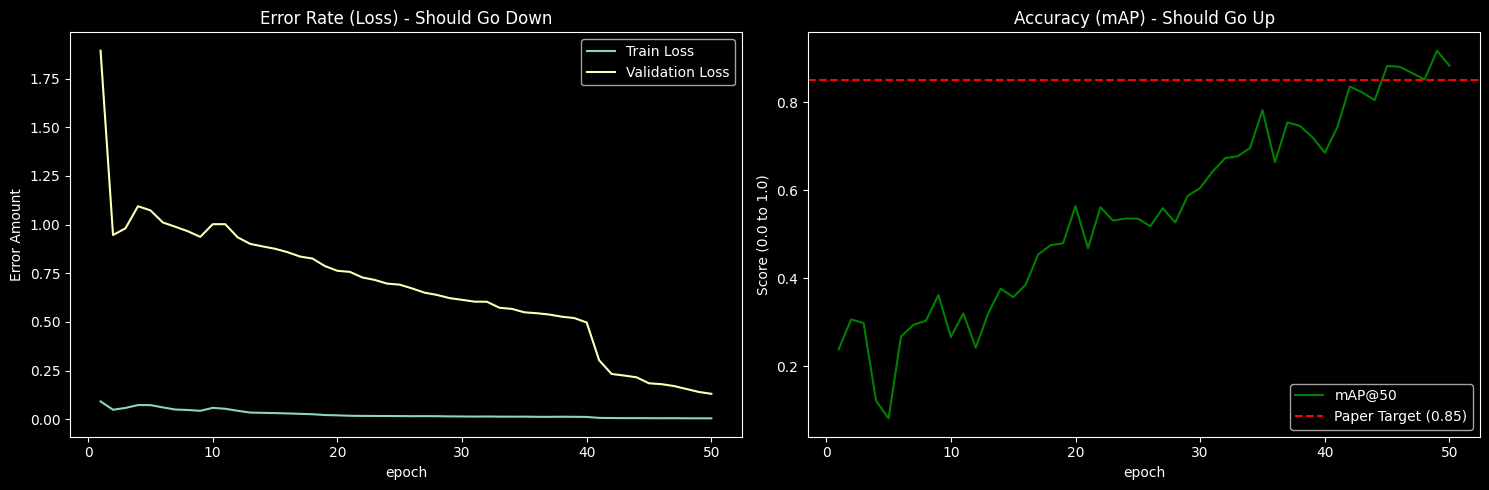

In [3]:
plt.style.use('dark_background')
plt.rcParams['grid.alpha'] = 0.5
%matplotlib inline

results_path = 'runs/detect/rtdetr_aircraft_finetune/results.csv'

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    # Print available columns for debugging
    print("Available columns:", df.columns.tolist())
    
    # Try to guess the correct column names
    # For loss: look for columns containing 'train' and 'loss'
    loss_cols = [col for col in df.columns if 'train' in col and 'loss' in col]
    if len(loss_cols) >= 2:
        # If we have separate box and cls losses, use them; else use first two
        train_loss_col = loss_cols[0]  # adjust as needed
        val_loss_col = loss_cols[1]    # adjust
    else:
        # Fallback to just 'train/loss' and 'val/loss' if available
        train_loss_col = 'train/loss' if 'train/loss' in df.columns else loss_cols[0]
        val_loss_col = 'val/loss' if 'val/loss' in df.columns else loss_cols[0] if len(loss_cols) > 0 else None
    
    # For mAP: look for column containing 'mAP50'
    map_col = [col for col in df.columns if 'mAP50' in col][0] if any('mAP50' in col for col in df.columns) else None
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graph 1: LOSS
    if train_loss_col and val_loss_col:
        sns.lineplot(data=df, x='epoch', y=train_loss_col, label='Train Loss', ax=ax[0])
        sns.lineplot(data=df, x='epoch', y=val_loss_col, label='Validation Loss', ax=ax[0])
        ax[0].set_title("Error Rate (Loss) - Should Go Down")
        ax[0].set_ylabel("Error Amount")
    else:
        print("Could not find loss columns.")
    
    # Graph 2: mAP
    if map_col:
        sns.lineplot(data=df, x='epoch', y=map_col, label='mAP@50', color='green', ax=ax[1])
        ax[1].set_title("Accuracy (mAP) - Should Go Up")
        ax[1].set_ylabel("Score (0.0 to 1.0)")
        ax[1].axhline(0.85, color='red', linestyle='--', label='Paper Target (0.85)')
        ax[1].legend()
    else:
        print("Could not find mAP50 column.")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Training is not finished or failed. No results.csv found at {results_path}")


0: 1280x1280 (no detections), 150.9ms
1: 1280x1280 (no detections), 150.9ms
2: 1280x1280 (no detections), 150.9ms
Speed: 12.8ms preprocess, 150.9ms inference, 0.9ms postprocess per image at shape (1, 3, 1280, 1280)
Results saved to /home/akash/Project Exhibition/RT-DETR/runs/detect/predict2


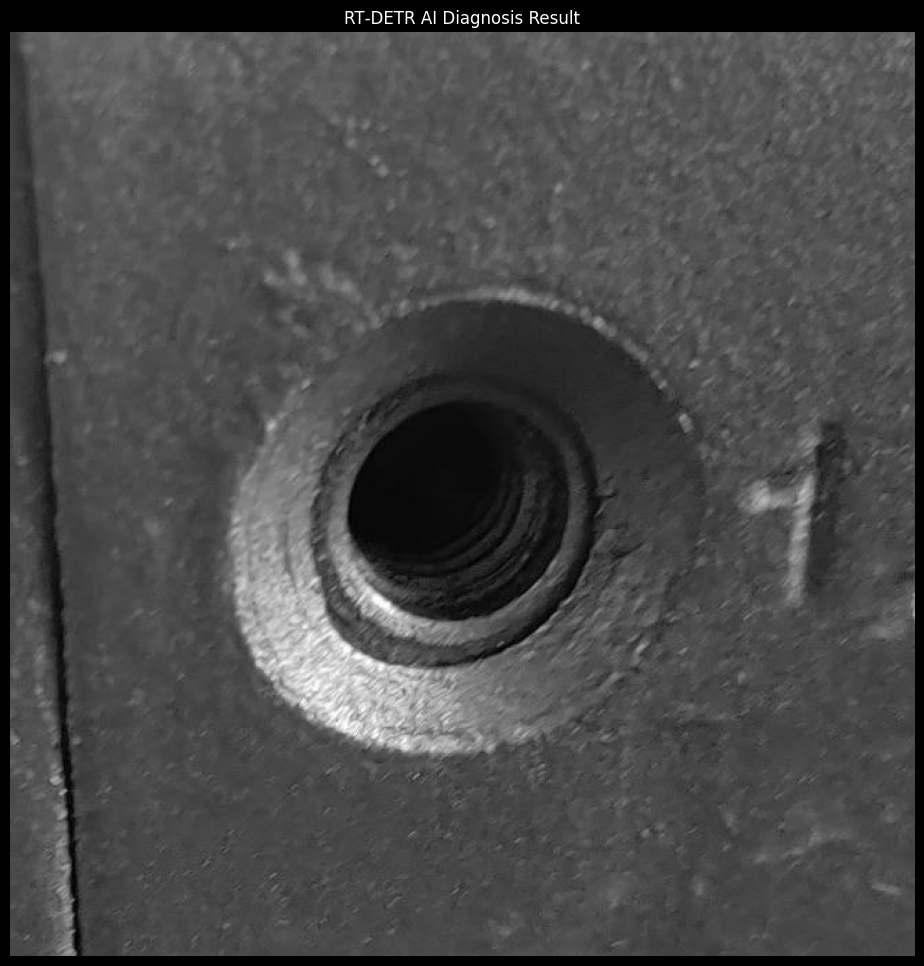

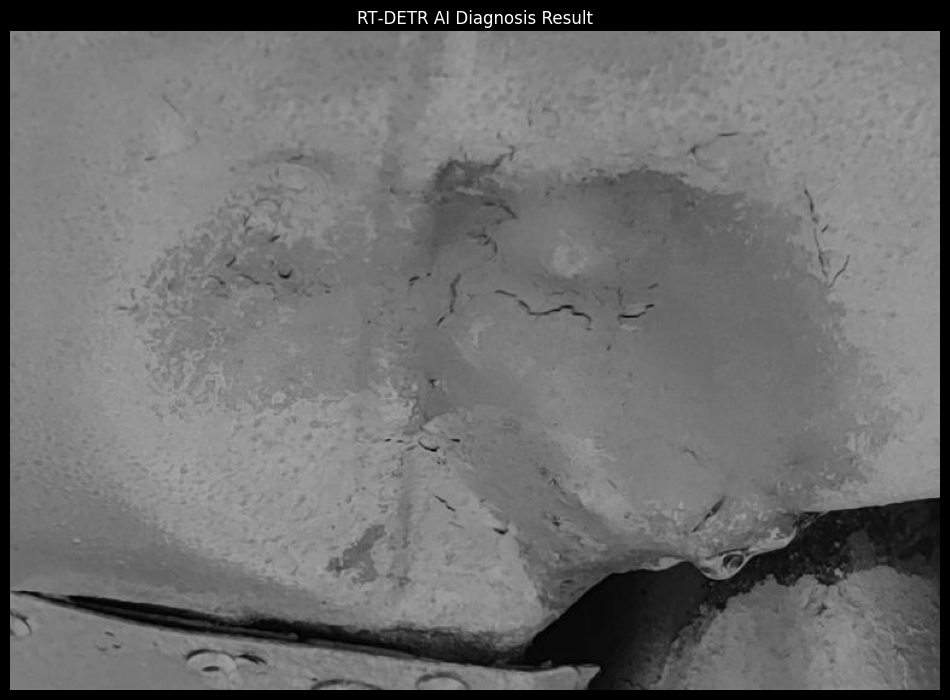

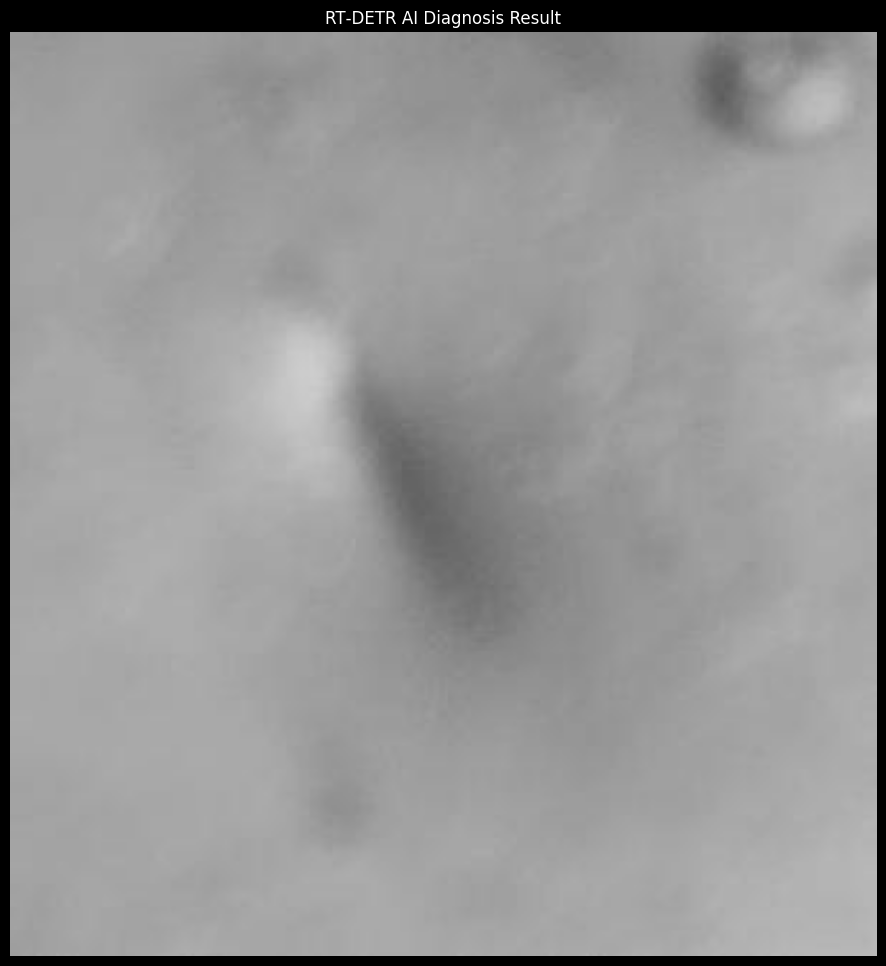

In [4]:
import glob

# 1. Load the BEST version of the RT‑DETR model (saved during training)
best_model_path = 'runs/detect/rtdetr_aircraft_finetune/weights/best.pt'
model = RTDETR(best_model_path)

# 2. Get a list of test images
test_images = glob.glob("aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/test/images/*.jpg")  # Finds all .jpg files in the test folder

# 3. Pick 3 random images to show
if len(test_images) > 0:
    selected_images = random.sample(test_images, min(3, len(test_images)))
    
    # 4. Run the Prediction
    # conf=0.25: The AI must be at least 25% sure to draw a box.
    # save=True: Save the resulting image with drawn boxes.
    results = model.predict(selected_images, conf=0.25, imgsz=1280, save=True)
    
    # 5. Show the results
    for result in results:
        # Plot the result (draw the boxes on the image array)
        im_array = result.plot()
        
        plt.figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("RT‑DETR AI Diagnosis Result")
        plt.show()
else:
    print("No images found in test/images. Check the folder path.")

Evaluating the RT‑DETR model on the validation set...
Ultralytics 8.4.14 🚀 Python-3.13.12 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1494.6±789.4 MB/s, size: 47.4 KB)
val: Scanning /home/akash/Project Exhibition/RT-DETR/aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/valid/labels.cache... 148 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 148/148 15.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.7it/s 5.8s.6ss
                   all        148        148       0.95      0.926      0.917      0.917
                 crack         43         43      0.888      0.953      0.936      0.935
                  dent         46         46      0.897          1      0.982      0.982
          missing-head         27    

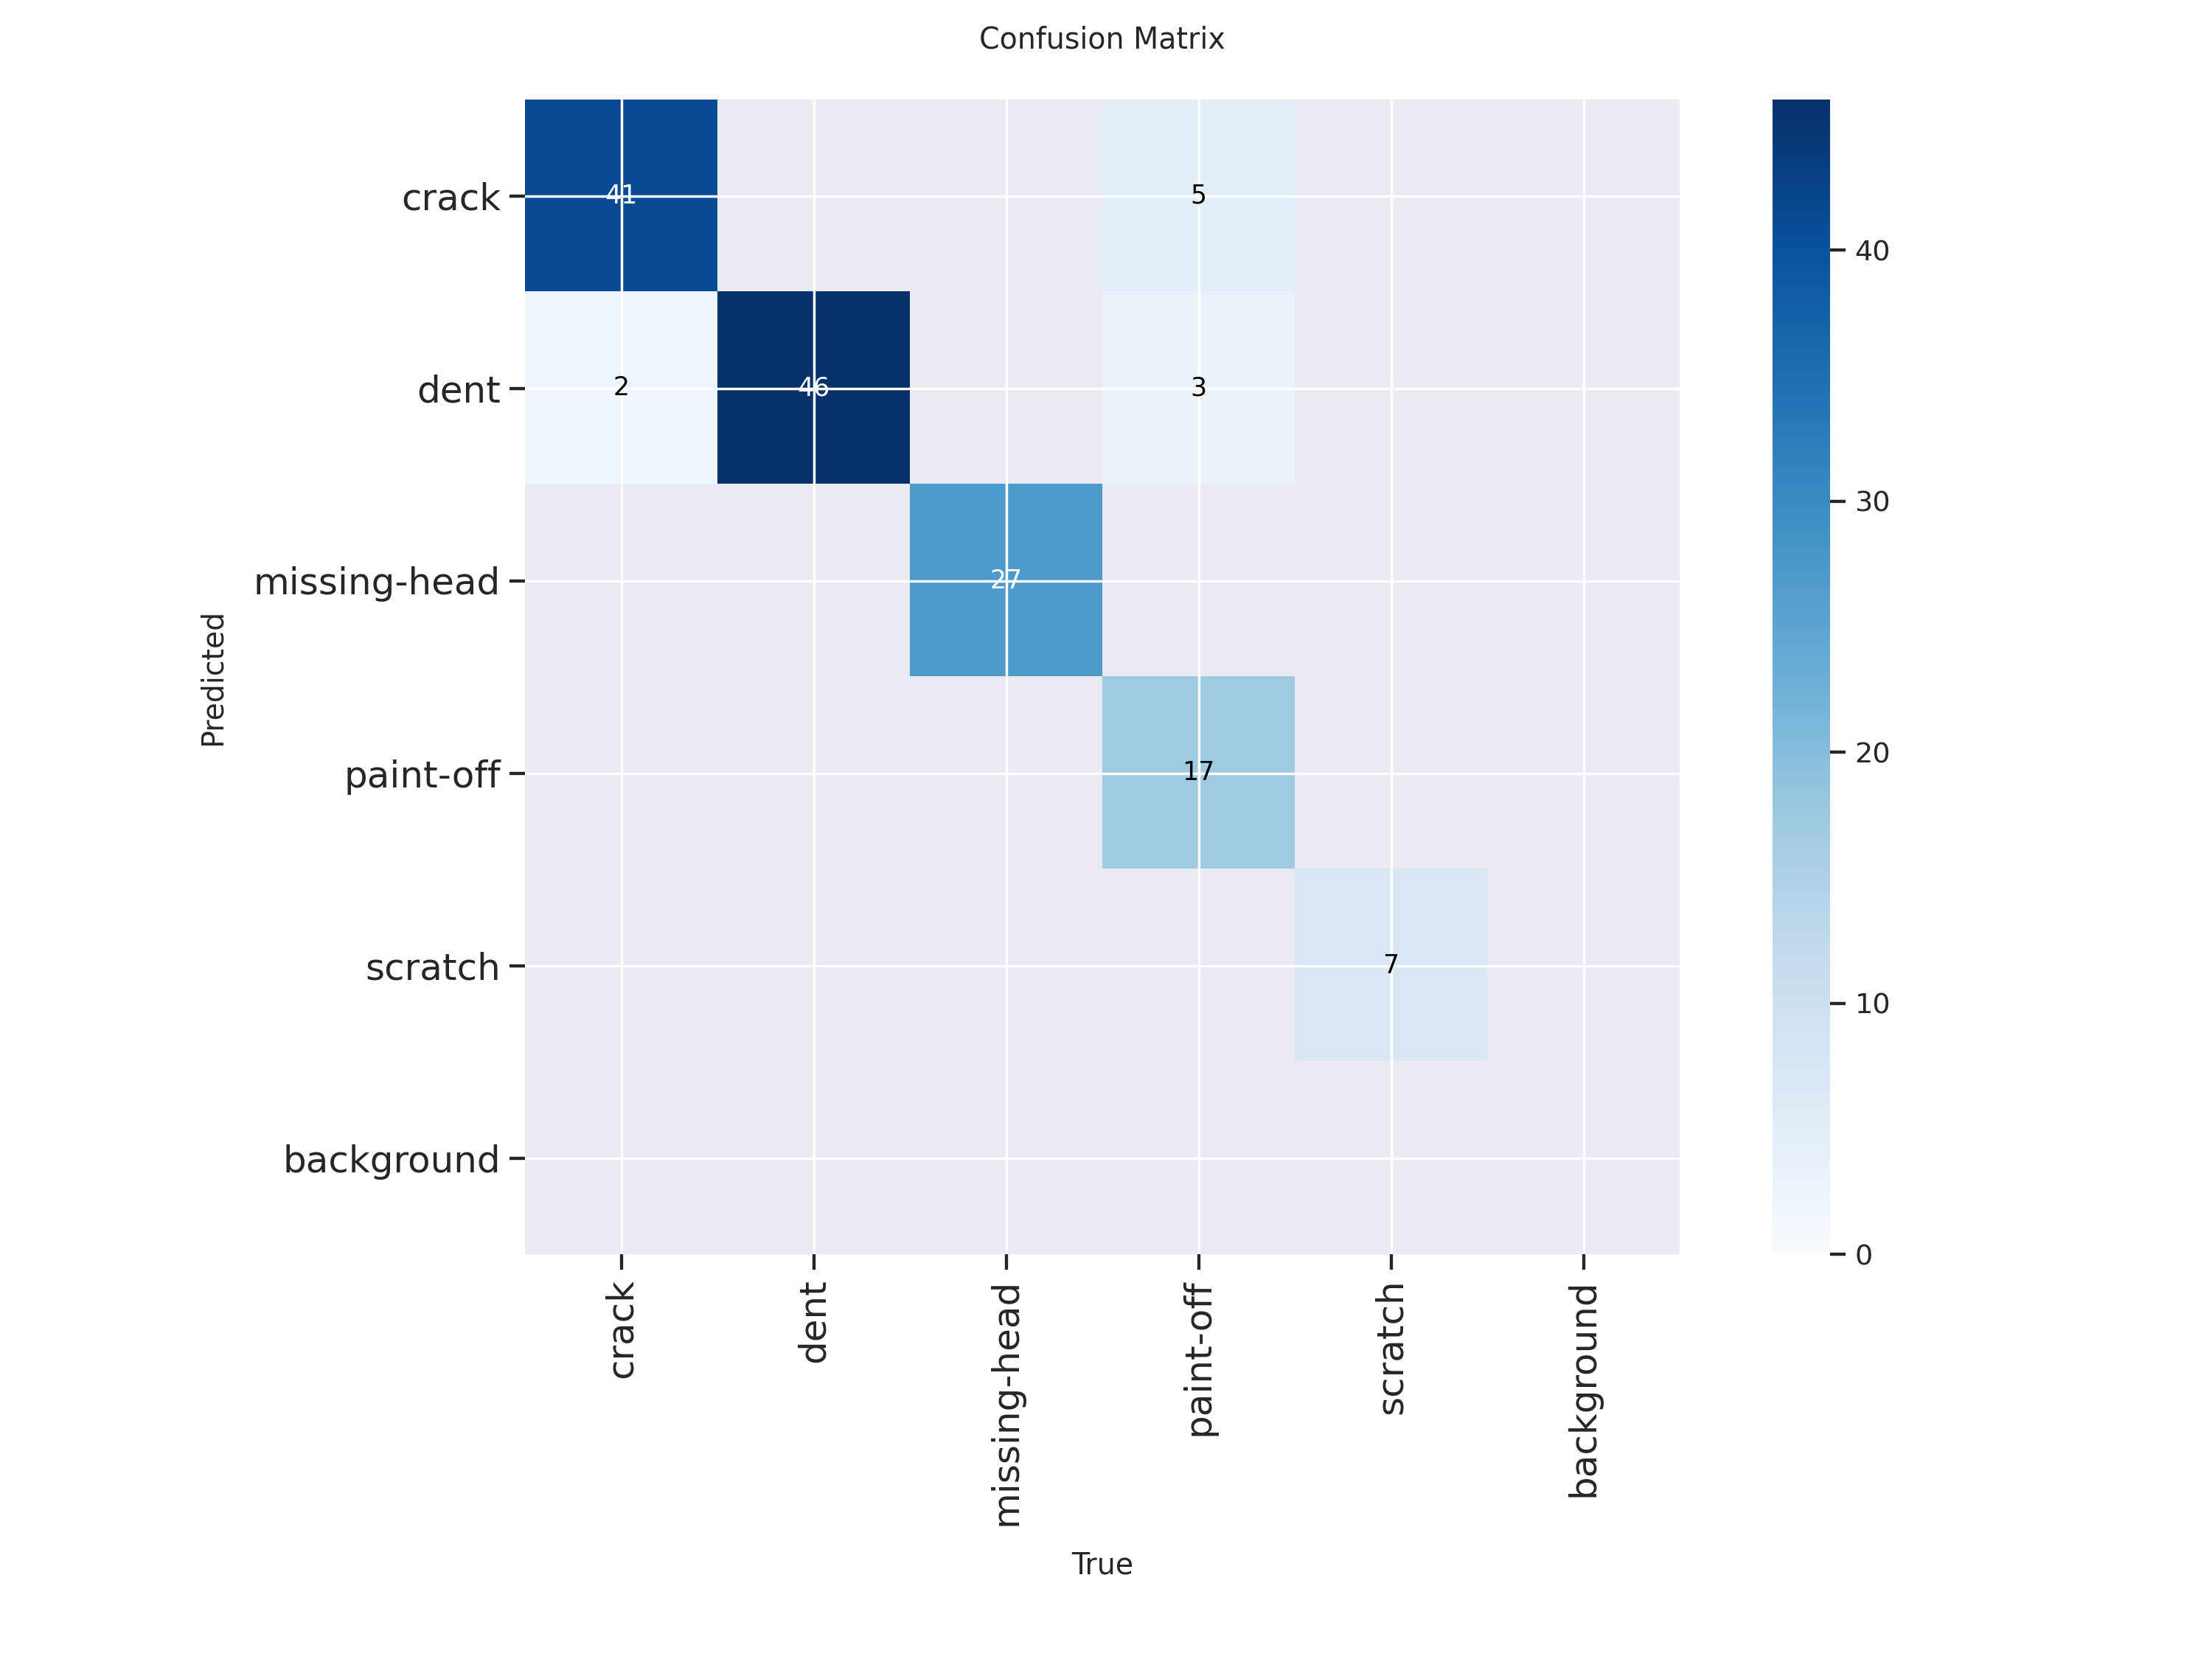

In [ ]:
from IPython.display import Image, display
sns.set_theme()

# 1. Run validation to calculate evaluation metrics
print("Evaluating the RT‑DETR model on the validation set...")

# Load your trained RT‑DETR model
model = RTDETR('runs/detect/rtdetr_aircraft_finetune/weights/best.pt')

# Validate using your dataset configuration
# (adjust the data path if it's different from the one used in training)
metrics = model.val(data='aircraft-skin-defects.v4-classification-isolated-5-classes-grayscale-prep.yolov8/data.yaml')

# Extract Precision and Recall
precision = metrics.box.mp
recall = metrics.box.mr

# Calculate F1 Score (Harmonic mean of Precision and Recall)
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

# 2. Print numeric evaluation metrics
print("\n--- Numeric Evaluation Metrics ---")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall:    {recall:.4f}")
print(f"F1-Score:       {f1_score:.4f}")
print(f"mAP50:          {metrics.box.map50:.4f}  <-- (Use this as your general 'Accuracy' metric)")
print(f"mAP50-95:       {metrics.box.map:.4f}")

print("\n*Note on Accuracy*: In Object Detection, standard 'Accuracy' (True Positives / Total) is generally replaced by mAP and F1-Score because the model must predict both the class AND the bounding box location. mAP50 is the industry standard proxy for object detection 'accuracy'.")

# 3. Locate and display the Evaluation Matrix (Confusion Matrix)
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print("\n--- Evaluation Matrix (Confusion Matrix) ---")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"\nConfusion matrix image not found at {confusion_matrix_path}")